# Version finale Pipeline A

[INFO] Device : cuda
[INFO] 150 patients train | 30 patients val | ['flair', 't1ce']
[INFO] Préchargement val…
  -> 1188 coupes (30 patients), 2 canaux
[INFO] Préchargement train (quelques minutes)…
  -> 5901 coupes (150 patients), 2 canaux

[§ U-Net] Entraînement (FLAIR + T1ce)…
  Ép  1/70  Dice(val WT)=0.3542  (best=0.3542)
  Ép  2/70  Dice(val WT)=0.5715  (best=0.5715)
  Ép  4/70  Dice(val WT)=0.6113  (best=0.6113)
  Ép  6/70  Dice(val WT)=0.7370  (best=0.7370)
  Ép  8/70  Dice(val WT)=0.7292  (best=0.7370)
  Ép 10/70  Dice(val WT)=0.7466  (best=0.7466)
  Ép 12/70  Dice(val WT)=0.6526  (best=0.7466)
  Ép 14/70  Dice(val WT)=0.7536  (best=0.7536)
  Ép 16/70  Dice(val WT)=0.7464  (best=0.7536)
  Ép 18/70  Dice(val WT)=0.7501  (best=0.7536)
  Ép 20/70  Dice(val WT)=0.7530  (best=0.7536)
  Ép 22/70  Dice(val WT)=0.7420  (best=0.7625)
  Ép 24/70  Dice(val WT)=0.7571  (best=0.7625)
  Ép 26/70  Dice(val WT)=0.7530  (best=0.7625)
  Ép 28/70  Dice(val WT)=0.7141  (best=0.7639)
  Ép 30/70  Di

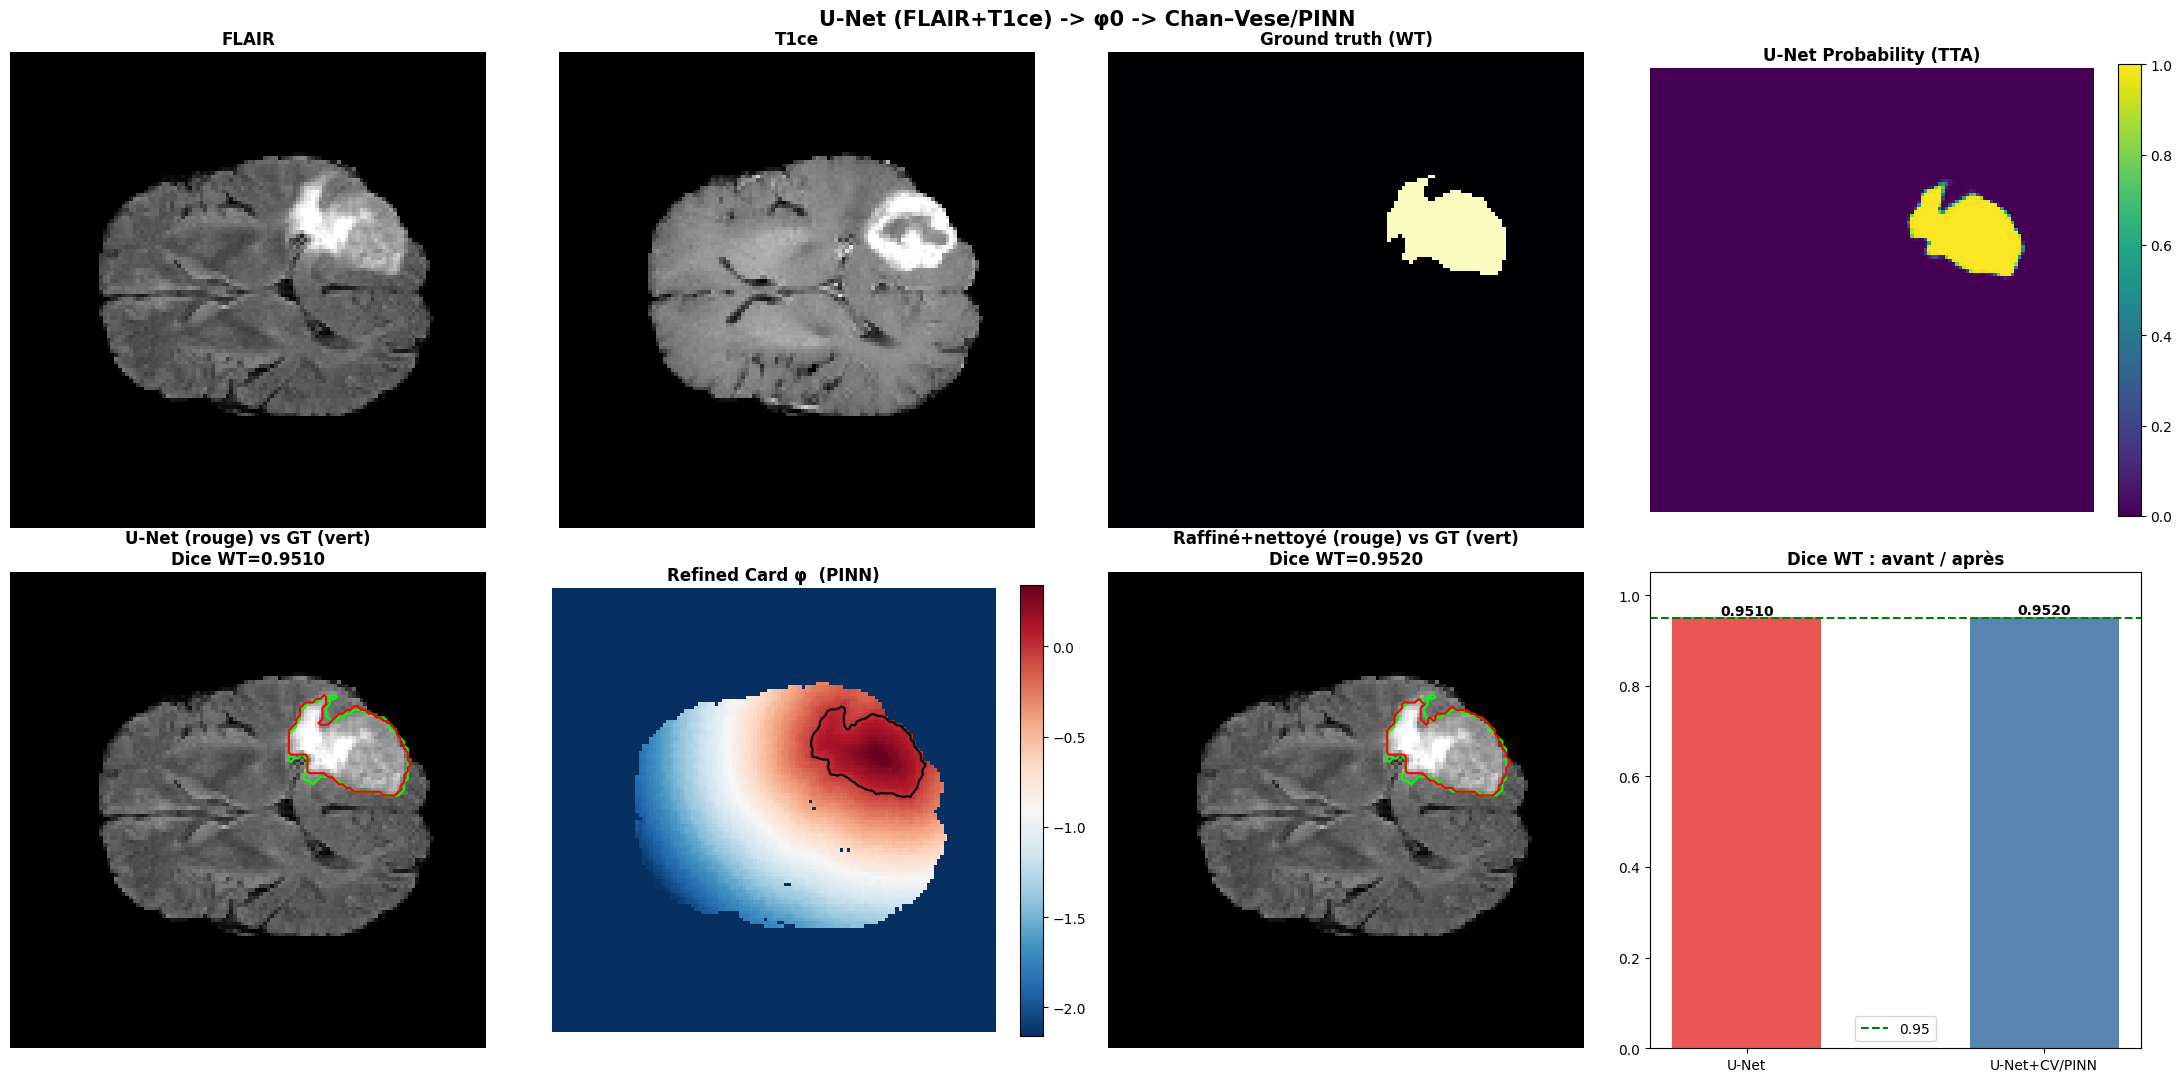

In [1]:
"""
╔══════════════════════════════════════════════════════════════════════════╗
║  PIPELINE U-Net -> φ0 -> Chan–Vese/PINN  —  FLAIR + T1ce UNIQUEMENT       ║
╠══════════════════════════════════════════════════════════════════════════╣
║  CHOIX DE MODÉLISATION (à justifier dans le mémoire) :                    ║
║  On restreint TOUT le pipeline à FLAIR + T1ce, conformément au cadre du   ║
║  projet :                                                                 ║
║    • FLAIR -> œdème et étendue de la tumeur (Whole Tumor).                ║
║    • T1ce  -> tissu actif rehaussé.                                       ║
║  Ces deux modalités couvrent les régions cliniquement décisives ; s'y     ║
║  limiter allège le modèle et renforce l'interprétabilité. C'est un CHOIX, ║
║  pas une limite technique.                                                ║
║                                                                          ║
║  Conséquence honnête : le Dice WT du U-Net sera un peu plus bas qu'avec   ║
║  4 modalités (le WT se voit aussi sur T2), mais le pipeline reste valable.║
║                                                                          ║
║  Corrections déjà intégrées (v2) : cast float32 (figure), raffineur       ║
║  GÉOMÉTRIQUE (lisse sans déplacer) + clean_mask, échantillon aléatoire.   ║
╚══════════════════════════════════════════════════════════════════════════╝
"""

import os, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import nibabel as nib
    HAS_NIBABEL = True
except ImportError:
    HAS_NIBABEL = False
from scipy.ndimage import distance_transform_edt, binary_fill_holes, label as cc_label

PI = 3.141592653589793
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device : {device}")
torch.manual_seed(0); np.random.seed(0)

DATA_DIR = ("/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")

config = {
    # ── Données / U-Net : FLAIR + T1ce UNIQUEMENT ──
    "modalities": ["flair", "t1ce"],     # <<< contrainte du projet (2 canaux)
    "img_size": 128,
    "n_train_patients": 150, "n_val_patients": 30,
    "max_slices_per_patient": 40,
    "epochs": 70, "batch_size": 16, "lr": 1e-3,
    "weight_decay": 1e-4, "dropout": 0.10, "base_ch": 32,
    "augment": True, "use_tta": True,

    # ── Sauvegarde / rechargement ──
    "checkpoint": "/kaggle/working/unet_flair_t1ce.pt",
    "train_unet": True,        # False -> charge le checkpoint (inférence seule)

    # ── Raffinement GÉOMÉTRIQUE (FLAIR+T1ce ; lisse + nettoie) ──
    "fourier_dim": 64, "fourier_scale": 6.0, "hidden": [128, 128, 128],
    "phi_scale": 4.0, "delta_eps": 1.0,
    "warmup_steps": 400, "refine_steps": 200, "refine_lr": 2e-3,
    "mu": 0.03, "l_flair": 0.0, "l_t1ce": 0.0, "w_anchor": 15.0,
    "n_points": 6000, "c_update_every": 25,
    "refine_eval_slices": 20,
}


# ═══════════════════════════════════════════════════════════
# §1  CHARGEMENT + AUGMENTATION + NETTOYAGE
# ═══════════════════════════════════════════════════════════

def _norm(img):
    b = img[img > 0]
    if len(b) == 0:
        return img.astype(np.float32)
    lo, hi = np.percentile(b, [1, 99])
    return np.clip((img - lo) / (hi - lo + 1e-8), 0, 1).astype(np.float32)


def load_volume(path, modalities):
    name = path.name

    def ff(s):
        for e in [".nii.gz", ".nii"]:
            f = path / f"{name}_{s}{e}"
            if f.exists():
                return str(f)
        raise FileNotFoundError(s)

    vols = [_norm(nib.load(ff(m)).get_fdata()) for m in modalities]
    sg = nib.load(ff("seg")).get_fdata().astype(np.int32)
    return vols, sg


def _resize(a, size, mode):
    t = torch.tensor(a, dtype=torch.float32)[None, None]
    if mode == "nearest":
        out = F.interpolate(t, size=(size, size), mode="nearest")
    else:
        out = F.interpolate(t, size=(size, size), mode="bilinear", align_corners=False)
    return out[0, 0].numpy()


class BraTSSlices(torch.utils.data.Dataset):
    """Coupes 2D : entrée = modalités empilées -> masque Whole-Tumor binaire."""
    def __init__(self, patient_paths, modalities, size, max_slices):
        Xs, Ys = [], []
        for p in patient_paths:
            vols, sg = load_volume(p, modalities)
            zs = [z for z in range(sg.shape[2]) if (sg[:, :, z] > 0).sum() > 30]
            if len(zs) > max_slices:
                zs = [zs[i] for i in np.linspace(0, len(zs) - 1, max_slices).astype(int)]
            for z in zs:
                X = np.stack([_resize(v[:, :, z], size, "bilinear") for v in vols], 0)
                Y = (_resize((sg[:, :, z] > 0).astype(np.float32), size, "nearest") > 0.5)
                Xs.append(X.astype(np.float16)); Ys.append(Y.astype(np.float16)[None])
        self.X = torch.tensor(np.array(Xs)); self.Y = torch.tensor(np.array(Ys))
        print(f"  -> {len(self.X)} coupes ({len(patient_paths)} patients), "
              f"{self.X.shape[1]} canaux")

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i].float(), self.Y[i].float()


def augment(X, Y):
    if torch.rand(1).item() < 0.5:
        X = torch.flip(X, [3]); Y = torch.flip(Y, [3])
    if torch.rand(1).item() < 0.5:
        X = torch.flip(X, [2]); Y = torch.flip(Y, [2])
    k = int(torch.randint(0, 4, (1,)).item())
    if k:
        X = torch.rot90(X, k, [2, 3]); Y = torch.rot90(Y, k, [2, 3])
    s = 1.0 + (torch.rand(X.shape[0], 1, 1, 1, device=X.device) - 0.5) * 0.2
    b = (torch.rand(X.shape[0], 1, 1, 1, device=X.device) - 0.5) * 0.1
    return torch.clamp(X * s + b, 0, 1), Y


def clean_mask(mask):
    """Bouche les trous et retire les petits îlots (< 10% de la plus grande composante)."""
    mask = binary_fill_holes(mask)
    lab, n = cc_label(mask)
    if n <= 1:
        return mask
    sizes = np.array([(lab == i).sum() for i in range(1, n + 1)])
    keep = np.zeros_like(mask)
    for i in range(1, n + 1):
        if sizes[i - 1] >= 0.10 * sizes.max():
            keep |= (lab == i)
    return keep


# ═══════════════════════════════════════════════════════════
# §2  U-NET 2D + TTA
# ═══════════════════════════════════════════════════════════

class DoubleConv(nn.Module):
    def __init__(self, ci, co, p=0.0):
        super().__init__()
        layers = [nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                  nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True)]
        if p > 0:
            layers.append(nn.Dropout2d(p))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_ch=2, base=32, p=0.1):
        super().__init__()
        self.d1 = DoubleConv(in_ch, base);        self.d2 = DoubleConv(base, base * 2)
        self.d3 = DoubleConv(base * 2, base * 4);  self.d4 = DoubleConv(base * 4, base * 8, p)
        self.pool = nn.MaxPool2d(2)
        self.bott = DoubleConv(base * 8, base * 16, p)
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2); self.u4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2);  self.u3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2);  self.u2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2);      self.u1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1))
        c3 = self.d3(self.pool(c2)); c4 = self.d4(self.pool(c3))
        b = self.bott(self.pool(c4))
        x = self.u4(torch.cat([self.up4(b), c4], 1))
        x = self.u3(torch.cat([self.up3(x), c3], 1))
        x = self.u2(torch.cat([self.up2(x), c2], 1))
        x = self.u1(torch.cat([self.up1(x), c1], 1))
        return self.out(x)


@torch.no_grad()
def predict_tta(model, X):
    ps = [torch.sigmoid(model(X)),
          torch.flip(torch.sigmoid(model(torch.flip(X, [3]))), [3]),
          torch.flip(torch.sigmoid(model(torch.flip(X, [2]))), [2])]
    return torch.stack(ps).mean(0)


# ═══════════════════════════════════════════════════════════
# §3  PERTES, MÉTRIQUE, ENTRAÎNEMENT
# ═══════════════════════════════════════════════════════════

_bce = nn.BCEWithLogitsLoss()


def dice_loss(logits, target, eps=1.0):
    p = torch.sigmoid(logits)
    num = 2 * (p * target).sum((1, 2, 3)) + eps
    den = p.sum((1, 2, 3)) + target.sum((1, 2, 3)) + eps
    return (1 - num / den).mean()


@torch.no_grad()
def dice_metric(logits, target, thr=0.5):
    p = (torch.sigmoid(logits) > thr).float()
    num = 2 * (p * target).sum((1, 2, 3))
    den = p.sum((1, 2, 3)) + target.sum((1, 2, 3))
    d = torch.where(den < 1e-6, torch.ones_like(den), num / den)
    return d.mean().item()


def train_unet(model, train_dl, val_dl, cfg):
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg["epochs"])
    best, best_state, patience, since = 0.0, None, 15, 0
    print("\n[§ U-Net] Entraînement (FLAIR + T1ce)…")
    for ep in range(1, cfg["epochs"] + 1):
        model.train()
        for X, Y in train_dl:
            X, Y = X.to(device), Y.to(device)
            if cfg["augment"]:
                X, Y = augment(X, Y)
            logit = model(X)
            loss = dice_loss(logit, Y) + _bce(logit, Y)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()

        model.eval(); ds = []
        with torch.no_grad():
            for X, Y in val_dl:
                X, Y = X.to(device), Y.to(device)
                ds.append(dice_metric(model(X), Y))
        vd = float(np.mean(ds))
        if vd > best:
            best, since = vd, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            since += 1
        if ep % 2 == 0 or ep == 1:
            print(f"  Ép {ep:2d}/{cfg['epochs']}  Dice(val WT)={vd:.4f}  (best={best:.4f})")
        if since >= patience:
            print(f"  [early stop] pas d'amélioration depuis {patience} époques.")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"[§ U-Net] Meilleur Dice WT moyen (val) = {best:.4f}")
    return model, best


# ═══════════════════════════════════════════════════════════
# §4  RAFFINEMENT GÉOMÉTRIQUE (longueur + ancrage φ0)
# ═══════════════════════════════════════════════════════════

class CVPINN(nn.Module):
    def __init__(self, fd=64, fs=6.0, hidden=(128, 128, 128), ps=4.0):
        super().__init__()
        self.phi_scale = ps
        self.register_buffer("B", torch.randn(2, fd) * fs)
        d = 2 * fd; layers = []
        for h in hidden:
            layers += [nn.Linear(d, h), nn.Tanh()]; d = h
        layers += [nn.Linear(d, 1)]
        self.mlp = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x, y):
        p = 2 * PI * torch.cat([x, y], -1) @ self.B
        return self.phi_scale * torch.tanh(self.mlp(torch.cat([torch.sin(p), torch.cos(p)], -1)))


def _g(u, v):
    return torch.autograd.grad(u, v, torch.ones_like(u), create_graph=True)[0]


def prob_to_phi0(prob, scale):
    mask = binary_fill_holes(prob > 0.5)
    if mask.sum() < 5:
        mask = prob > 0.5
    din = distance_transform_edt(mask); dout = distance_transform_edt(~mask)
    phi0 = (din - dout).astype(np.float32)
    return phi0 / (np.abs(phi0).max() + 1e-8) * scale


@torch.no_grad()
def _consts(model, X, Y, IFL, IT1, eps):
    phi = model(X, Y)
    Hin = 0.5 * (1 + (2 / PI) * torch.atan(phi / eps)); Hout = 1 - Hin
    wm = lambda I, w: (I * w).sum() / (w.sum() + 1e-8)
    return wm(IFL, Hin), wm(IFL, Hout), wm(IT1, Hin), wm(IT1, Hout)


def refine(flair, t1ce, prob, brain_mask, cfg):
    H, W = flair.shape
    phi0 = prob_to_phi0(prob, cfg["phi_scale"])
    rr, cc = np.where(brain_mask)
    Xn = torch.tensor(cc / (W - 1), dtype=torch.float32, device=device).view(-1, 1)
    Yn = torch.tensor(rr / (H - 1), dtype=torch.float32, device=device).view(-1, 1)
    IFL = torch.tensor(flair[rr, cc], dtype=torch.float32, device=device).view(-1, 1)
    IT1 = torch.tensor(t1ce[rr, cc], dtype=torch.float32, device=device).view(-1, 1)
    P0 = torch.tensor(phi0[rr, cc], dtype=torch.float32, device=device).view(-1, 1)
    N = Xn.shape[0]

    model = CVPINN(cfg["fourier_dim"], cfg["fourier_scale"], cfg["hidden"], cfg["phi_scale"]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["refine_lr"])
    for _ in range(cfg["warmup_steps"]):
        idx = torch.randint(0, N, (cfg["n_points"],), device=device)
        loss = ((model(Xn[idx], Yn[idx]) - P0[idx]) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()

    eps = cfg["delta_eps"]
    use_data = (cfg["l_flair"] > 0) or (cfg["l_t1ce"] > 0)
    consts = _consts(model, Xn, Yn, IFL, IT1, eps) if use_data else (0, 0, 0, 0)
    for ep in range(1, cfg["refine_steps"] + 1):
        if use_data and ep % cfg["c_update_every"] == 0:
            consts = _consts(model, Xn, Yn, IFL, IT1, eps)
        idx = torch.randint(0, N, (cfg["n_points"],), device=device)
        x = Xn[idx].detach().requires_grad_(True); y = Yn[idx].detach().requires_grad_(True)
        phi = model(x, y); px = _g(phi, x); py = _g(phi, y)
        delta = (1.0 / PI) * eps / (eps ** 2 + phi ** 2)
        length = (delta * torch.sqrt(px ** 2 + py ** 2 + 1e-12)).mean()
        fid = 0.0
        if use_data:
            Hin = 0.5 * (1 + (2 / PI) * torch.atan(phi / eps)); Hout = 1 - Hin
            c1FL, c2FL, c1T1, c2T1 = consts
            fid = (cfg["l_flair"] * ((IFL[idx] - c1FL) ** 2 * Hin).mean()
                   + cfg["l_flair"] * ((IFL[idx] - c2FL) ** 2 * Hout).mean()
                   + cfg["l_t1ce"] * ((IT1[idx] - c1T1) ** 2 * Hin).mean()
                   + cfg["l_t1ce"] * ((IT1[idx] - c2T1) ** 2 * Hout).mean())
        anchor = ((phi - P0[idx]) ** 2).mean()
        E = cfg["mu"] * length + fid + cfg["w_anchor"] * anchor
        opt.zero_grad(); E.backward(); opt.step()

    with torch.no_grad():
        gx = torch.linspace(0, 1, W, device=device).repeat(H).view(-1, 1)
        gy = torch.repeat_interleave(torch.linspace(0, 1, H, device=device), W).view(-1, 1)
        phi = model(gx, gy).cpu().numpy().reshape(H, W)
    phi[~brain_mask] = phi[brain_mask].min()
    return phi


def dice_bin(p, g):
    i = (p & g).sum(); d = p.sum() + g.sum()
    return 1.0 if d < 1e-8 else 2.0 * i / d


# ═══════════════════════════════════════════════════════════
# §5  VISUALISATION (cast float32)
# ═══════════════════════════════════════════════════════════

def _f32(a):
    return np.asarray(a, dtype=np.float32)


def visualize(flair, t1ce, gt, prob, unet_mask, phi, refined_mask, d_unet, d_ref, save):
    flair, t1ce, gt, prob, phi = map(_f32, (flair, t1ce, gt, prob, phi))
    um, rm = _f32(unet_mask), _f32(refined_mask)

    fig, ax = plt.subplots(2, 4, figsize=(22, 11))
    ax[0, 0].imshow(flair, cmap="gray"); ax[0, 0].set_title("FLAIR", fontweight="bold"); ax[0, 0].axis("off")
    ax[0, 1].imshow(t1ce, cmap="gray"); ax[0, 1].set_title("T1ce", fontweight="bold"); ax[0, 1].axis("off")
    ax[0, 2].imshow(gt, cmap="magma"); ax[0, 2].set_title("Ground truth (WT)", fontweight="bold"); ax[0, 2].axis("off")
    im = ax[0, 3].imshow(prob, cmap="viridis", vmin=0, vmax=1)
    ax[0, 3].set_title("U-Net Probability (TTA)", fontweight="bold"); ax[0, 3].axis("off")
    plt.colorbar(im, ax=ax[0, 3], fraction=0.046)

    ax[1, 0].imshow(flair, cmap="gray")
    ax[1, 0].contour(gt, levels=[0.5], colors=["lime"], linewidths=1.5)
    ax[1, 0].contour(um, levels=[0.5], colors=["red"], linewidths=1.5)
    ax[1, 0].set_title(f"U-Net (rouge) vs GT (vert)\nDice WT={d_unet:.4f}", fontweight="bold"); ax[1, 0].axis("off")
    im = ax[1, 1].imshow(phi, cmap="RdBu_r"); ax[1, 1].contour(phi, levels=[0.0], colors=["k"], linewidths=1.5)
    ax[1, 1].set_title("Refined Card φ  (PINN)", fontweight="bold"); ax[1, 1].axis("off")
    plt.colorbar(im, ax=ax[1, 1], fraction=0.046)
    ax[1, 2].imshow(flair, cmap="gray")
    ax[1, 2].contour(gt, levels=[0.5], colors=["lime"], linewidths=1.5)
    ax[1, 2].contour(rm, levels=[0.5], colors=["red"], linewidths=1.5)
    ax[1, 2].set_title(f"Raffiné+nettoyé (rouge) vs GT (vert)\nDice WT={d_ref:.4f}", fontweight="bold"); ax[1, 2].axis("off")
    bars = ax[1, 3].bar(["U-Net", "U-Net+CV/PINN"], [d_unet, d_ref], color=["#E53935", "#3b6ea5"], alpha=0.85, width=0.5)
    ax[1, 3].axhline(0.95, color="green", lw=1.5, ls="--", label="0.95")
    for b, d in zip(bars, [d_unet, d_ref]):
        ax[1, 3].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005, f"{d:.4f}", ha="center", fontweight="bold")
    ax[1, 3].set_ylim(0, 1.05); ax[1, 3].legend(); ax[1, 3].set_title("Dice WT : avant / après", fontweight="bold")
    fig.suptitle("U-Net (FLAIR+T1ce) -> φ0 -> Chan–Vese/PINN", fontsize=15, fontweight="bold")

    plt.tight_layout()
    try:
        plt.savefig(save, dpi=150); print(f"[INFO] Figure → {save}")
    except Exception as e:
        print(f"[WARN] figure non sauvegardée : {e}")
    plt.show(); plt.close(fig)


# ═══════════════════════════════════════════════════════════
# §6  MAIN
# ═══════════════════════════════════════════════════════════

def main():
    if not HAS_NIBABEL:
        raise ImportError("pip install nibabel")
    SAVE = "/kaggle/working/pipeline_flair_t1ce.png"
    sz = config["img_size"]; mods = config["modalities"]
    assert "flair" in mods and "t1ce" in mods, "FLAIR et T1ce sont requis."
    i_fl = mods.index("flair"); i_t1 = mods.index("t1ce")

    pats = sorted([d for d in Path(DATA_DIR).iterdir() if d.is_dir()])
    ntr, nva = config["n_train_patients"], config["n_val_patients"]
    train_p, val_p = pats[:ntr], pats[ntr:ntr + nva]
    print(f"[INFO] {len(train_p)} patients train | {len(val_p)} patients val | {mods}")

    print("[INFO] Préchargement val…")
    val_ds = BraTSSlices(val_p, mods, sz, config["max_slices_per_patient"])
    val_dl = torch.utils.data.DataLoader(val_ds, batch_size=config["batch_size"])

    unet = UNet(len(mods), config["base_ch"], config["dropout"]).to(device)

    if config["train_unet"]:
        print("[INFO] Préchargement train (quelques minutes)…")
        train_ds = BraTSSlices(train_p, mods, sz, config["max_slices_per_patient"])
        train_dl = torch.utils.data.DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
        unet, best_val = train_unet(unet, train_dl, val_dl, config)
        torch.save(unet.state_dict(), config["checkpoint"])
        print(f"[INFO] Modèle sauvegardé → {config['checkpoint']}")
    else:
        if not os.path.exists(config["checkpoint"]):
            raise FileNotFoundError(f"Checkpoint introuvable : {config['checkpoint']}")
        unet.load_state_dict(torch.load(config["checkpoint"], map_location=device))
        unet.eval()
        with torch.no_grad():
            best_val = float(np.mean([dice_metric(unet(X.to(device)), Y.to(device)) for X, Y in val_dl]))
        print(f"[INFO] Modèle rechargé. Dice WT moyen (val) = {best_val:.4f}")

    # ── Échantillon ALÉATOIRE représentatif ──
    rng = np.random.default_rng(0)
    cand = [i for i in range(len(val_ds)) if float(val_ds.Y[i].sum()) > 50]
    K = min(config["refine_eval_slices"], len(cand))
    sel = rng.choice(cand, size=K, replace=False)

    du_list, dr_list, demo = [], [], None
    print(f"\n[§ Raffinement géométrique] Moyenne sur {K} coupes val (aléatoires)…")
    unet.eval()
    for j, k in enumerate(sel):
        k = int(k)
        X = val_ds.X[k:k + 1].float().to(device)
        gt = val_ds.Y[k, 0].numpy().astype(np.float32).astype(bool)
        prob = (predict_tta(unet, X) if config["use_tta"]
                else torch.sigmoid(unet(X)))[0, 0].cpu().numpy().astype(np.float32)
        flair = val_ds.X[k, i_fl].numpy().astype(np.float32)
        t1ce = val_ds.X[k, i_t1].numpy().astype(np.float32)
        brain = flair > 0.02
        um = prob > 0.5; du = dice_bin(um, gt)
        phi = refine(flair, t1ce, prob, brain, config)
        rm = clean_mask((phi > 0) & brain); dr = dice_bin(rm, gt)
        du_list.append(du); dr_list.append(dr)
        if demo is None or dr > demo[8]:
            demo = (flair, t1ce, gt, prob, um, phi, rm, du, dr)

    print("\n  ── RÉSULTATS (Dice WT binaire — FLAIR + T1ce) ────")
    print(f"  U-Net — moyenne validation (toutes coupes) : {best_val:.4f}")
    print(f"  U-Net — moyenne ({K} coupes aléatoires)     : {np.mean(du_list):.4f}")
    print(f"  U-Net + CV/PINN + nettoyage — moyenne ({K})  : {np.mean(dr_list):.4f}")
    print(f"  Δ raffinement moyen                          : {np.mean(dr_list) - np.mean(du_list):+.4f}")
    print(f"  Meilleure coupe (U-Net+CV/PINN)              : {max(dr_list):.4f}")

    visualize(*demo, SAVE)
    return unet, best_val


if __name__ == "__main__":
    main()

In [3]:
# =====================================================================
#  MEASUREMENT CELL -- Chapter 5, Tables 5.1, 5.2 and 5.3
#  Version matched to the 150-patient pipeline (no disk cache).
#  Adds the two columns that Table 5.3 still needs: the curvature
#  after signed-distance reprojection, and the eikonal deviation.
#
#  Run this AFTER the Pipeline A cell, in the same session.
#  Nothing is retrained and the cache is not rebuilt: the U-Net is
#  reused (or reloaded from the checkpoint) and only the refinement
#  stage is re-run.
#
#  The patient split (split_seed=42) and the evaluation slices
#  (default_rng(0)) are reproduced exactly as in main(), so every
#  number below is paired with the ones already reported.
#
#  Output: LaTeX-ready rows to paste into chap4.tex.
# =====================================================================

import numpy as np
import torch
from pathlib import Path
from scipy.ndimage import distance_transform_edt, binary_fill_holes


# ---------------------------------------------------------------------
#  1. Metrics
# ---------------------------------------------------------------------
def _delta_eps(phi, eps):
    return (1.0 / np.pi) * eps / (eps ** 2 + phi ** 2)


def contour_length(phi, eps=1.0, h=1.0):
    """Length(phi) -- Eq. (5.3)."""
    gy, gx = np.gradient(phi.astype(np.float64), h)
    return float((h ** 2) * np.sum(_delta_eps(phi, eps) * np.sqrt(gx ** 2 + gy ** 2)))


def mean_abs_curvature(phi, eps=1.0, h=1.0):
    """|kappa|(phi) -- Eq. (5.4), closed formula (3.23).

    NOTE: this is a property of the CONTOUR only when the field is well
    conditioned, i.e. |grad phi| is roughly constant near the zero level
    set. The denominator below carries |grad phi|^3, so a field that
    flattens near its zero crossing inflates the measured curvature.
    Compare with sdf_abs_curvature() and eikonal_deviation() below.
    """
    phi = phi.astype(np.float64)
    gy, gx = np.gradient(phi, h)
    gxy, gxx = np.gradient(gx, h)
    gyy, gyx = np.gradient(gy, h)
    num = gxx * gy ** 2 - 2.0 * gxy * gx * gy + gyy * gx ** 2
    den = (gx ** 2 + gy ** 2) ** 1.5 + 1e-8
    w = _delta_eps(phi, eps)
    return float(np.sum(w * np.abs(num / den)) / (np.sum(w) + 1e-12))


def to_signed_distance(phi, scale=None):
    """Rebuild a signed-distance function carrying the SAME zero level set.

    This removes the parameterisation of the field and keeps only its
    geometry, so that the curvature measured afterwards is a property of
    the contour alone.
    """
    m = phi > 0
    if m.sum() < 5 or (~m).sum() < 5:
        return None
    m = binary_fill_holes(m)
    sd = (distance_transform_edt(m) - distance_transform_edt(~m)).astype(np.float64)
    if scale is not None:
        sd = sd / (np.abs(sd).max() + 1e-8) * scale
    return sd


def sdf_abs_curvature(phi, eps=1.0, h=1.0, scale=4.0):
    """|kappa| measured after reprojection onto a signed-distance function.

    CAVEAT, to state in the thesis: the reprojection goes through the
    binary mask (phi > 0), so the rebuilt contour is rasterised on the
    pixel grid and its discrete curvature is biased UPWARDS. On an exact
    disc of radius 40 this returns about 0.131 where the true curvature is
    0.025. The absolute value is therefore not a curvature estimate.

    What it IS good for: the bias depends only on the contour, not on the
    field carrying it. Feeding it an exact signed-distance function and a
    tanh-squashed field with the SAME zero level set returns the same
    0.131 in both cases, whereas the raw curvature differs. The
    before/after COMPARISON is thus meaningful even though the level is
    not, which is exactly what Table 5.3 needs.
    """
    sd = to_signed_distance(phi, scale)
    return np.nan if sd is None else mean_abs_curvature(sd, eps, h)


def eikonal_deviation(phi, eps=1.0, h=1.0):
    """Scale-free deviation from |grad phi| = const near the zero level set.

    Returns std(|grad phi|)/mean(|grad phi|), weighted by delta_eps. It is
    0 for an exact signed-distance function and grows as the field loses
    that property. Being a ratio, it is invariant under phi -> c*phi, so
    phi_0 and phi_theta can be compared even though their scalings differ.
    """
    gy, gx = np.gradient(phi.astype(np.float64), h)
    g = np.sqrt(gx ** 2 + gy ** 2)
    w = _delta_eps(phi, eps)
    mu = np.sum(w * g) / (np.sum(w) + 1e-12)
    var = np.sum(w * (g - mu) ** 2) / (np.sum(w) + 1e-12)
    return float(np.sqrt(var) / (mu + 1e-12))


def hd95(pred, gt):
    """Symmetric 95th-percentile Hausdorff distance -- Eq. (5.2), in pixels.
    Returns nan when either mask is empty (undefined, not zero)."""
    pred = np.asarray(pred, bool)
    gt = np.asarray(gt, bool)
    if pred.sum() == 0 or gt.sum() == 0:
        return np.nan

    def _bnd(m):
        er = np.zeros_like(m)
        er[1:-1, 1:-1] = (m[1:-1, 1:-1] & m[:-2, 1:-1] & m[2:, 1:-1]
                          & m[1:-1, :-2] & m[1:-1, 2:])
        return m & ~er

    bp, bg = _bnd(pred), _bnd(gt)
    if bp.sum() == 0 or bg.sum() == 0:
        return np.nan
    d_gt = distance_transform_edt(~bg)
    d_pr = distance_transform_edt(~bp)
    return float(max(np.percentile(d_gt[bp], 95), np.percentile(d_pr[bg], 95)))


# ---------------------------------------------------------------------
#  2. Reproduce exactly the split and the slices used by main()
#     (150-patient pipeline: no disk cache, BraTSSlices is rebuilt)
# ---------------------------------------------------------------------
mods = config["modalities"]
i_fl = mods.index("flair")
i_t1 = mods.index("t1ce")
sz = config["img_size"]

pats = sorted([d for d in Path(DATA_DIR).iterdir() if d.is_dir()])
ntr, nva = config["n_train_patients"], config["n_val_patients"]
val_p = pats[ntr:ntr + nva]

print("[INFO] Reloading the validation set...")
val_ds = BraTSSlices(val_p, mods, sz, config["max_slices_per_patient"])

try:
    unet
    print("[INFO] Reusing the U-Net already in memory.")
except NameError:
    unet = UNet(len(mods), config["base_ch"], config["dropout"]).to(device)
    unet.load_state_dict(torch.load(config["checkpoint"], map_location=device))
    print("[INFO] U-Net reloaded from the checkpoint.")
unet.eval()

rng = np.random.default_rng(0)
cand = [i for i in range(len(val_ds)) if float(val_ds.Y[i].sum()) > 50]
K = min(config["refine_eval_slices"], len(cand))
sel = [int(k) for k in rng.choice(cand, size=K, replace=False)]
print(f"[INFO] {K} evaluation slices reproduced.")


def _slice_data(k):
    X = val_ds.X[k:k + 1].float().to(device)
    gt = val_ds.Y[k, 0].numpy().astype(np.float32).astype(bool)
    prob = (predict_tta(unet, X) if config["use_tta"]
            else torch.sigmoid(unet(X)))[0, 0].detach().cpu().numpy().astype(np.float32)
    flair = val_ds.X[k, i_fl].numpy().astype(np.float32)
    t1ce = val_ds.X[k, i_t1].numpy().astype(np.float32)
    return flair, t1ce, gt, prob, flair > 0.02


# ---------------------------------------------------------------------
#  3. Pass 1 -- Tables 5.1 and 5.3 (reported configuration)
# ---------------------------------------------------------------------
eps = config["delta_eps"]
ps = config["phi_scale"]
fields = []
keys = ["du", "dr", "h0", "h1", "L0", "L1", "k0", "k1", "s0", "s1", "e0", "e1"]
acc = {k: [] for k in keys}

print(f"\n[PASS 1] Dice, HD95 and contour regularity over {K} slices...")
for j, k in enumerate(sel, 1):
    flair, t1ce, gt, prob, brain = _slice_data(k)
    um = prob > 0.5
    phi0 = prob_to_phi0(prob, ps)
    phi = refine(flair, t1ce, prob, brain, config)
    rm = clean_mask((phi > 0) & brain)
    fields.append({"k": k, "phi0": phi0.copy(),"phi": phi.copy(), "brain": brain.copy()})

    acc["du"].append(dice_bin(um, gt))
    acc["dr"].append(dice_bin(rm, gt))
    acc["h0"].append(hd95(um, gt))
    acc["h1"].append(hd95(rm, gt))
    acc["L0"].append(contour_length(phi0, eps))
    acc["L1"].append(contour_length(phi, eps))
    acc["k0"].append(mean_abs_curvature(phi0, eps))
    acc["k1"].append(mean_abs_curvature(phi, eps))
    acc["s0"].append(sdf_abs_curvature(phi0, eps, scale=ps))
    acc["s1"].append(sdf_abs_curvature(phi, eps, scale=ps))
    acc["e0"].append(eikonal_deviation(phi0, eps))
    acc["e1"].append(eikonal_deviation(phi, eps))
    if j % 5 == 0:
        print(f"   {j}/{K} slices")

m = {key: float(np.nanmean(v)) for key, v in acc.items()}


def pct(a, b):
    return 100.0 * (b - a) / (abs(a) + 1e-12)


print("\n" + "=" * 70)
print(" TABLE 5.1  --  Dice and HD95")
print("=" * 70)
print(f"  U-Net, {K} evaluation slices        Dice={m['du']:.4f}   HD95={m['h0']:.2f}")
print(f"  U-Net + refinement + cleanup       Dice={m['dr']:.4f}   HD95={m['h1']:.2f}")
print(f"  Delta                              Dice={m['dr']-m['du']:+.4f}  HD95={m['h1']-m['h0']:+.2f}")
print(f"  Best slice                         Dice={max(acc['dr']):.4f}")
print("\n  LaTeX rows:")
print(f"    U-Net --- mean over the ${K}$ evaluation slices     & ${m['du']:.4f}$ & ${m['h0']:.2f}$ \\\\")
print(f"    U-Net $+$ geometric refinement $+$ cleanup         & ${m['dr']:.4f}$ & ${m['h1']:.2f}$ \\\\")
print(f"    $\\Delta$ due to refinement (mean)                  & ${m['dr']-m['du']:+.4f}$ & ${m['h1']-m['h0']:+.2f}$ \\\\")
print(f"    Best slice (U-Net $+$ refinement)                  & ${max(acc['dr']):.4f}$ & --- \\\\")

print("\n" + "=" * 70)
print(" TABLE 5.3  --  contour regularity")
print("=" * 70)
print(f"  Length(phi)                 {m['L0']:8.2f} -> {m['L1']:8.2f}   ({pct(m['L0'], m['L1']):+.1f} %)")
print(f"  |kappa| on the raw field    {m['k0']:8.4f} -> {m['k1']:8.4f}   ({pct(m['k0'], m['k1']):+.1f} %)")
print(f"  |kappa| after SDF reproj.   {m['s0']:8.4f} -> {m['s1']:8.4f}   ({pct(m['s0'], m['s1']):+.1f} %)")
print(f"  eikonal deviation           {m['e0']:8.4f} -> {m['e1']:8.4f}   ({pct(m['e0'], m['e1']):+.1f} %)")
print("\n  LaTeX rows:")
print(f"    Before refinement ($\\phi_0$)        & ${m['L0']:.2f}$ & ${m['k0']:.4f}$ & ${m['s0']:.4f}$ & ${m['e0']:.3f}$ & ${m['du']:.4f}$ \\\\")
print(f"    After refinement ($\\phi_\\vartheta$) & ${m['L1']:.2f}$ & ${m['k1']:.4f}$ & ${m['s1']:.4f}$ & ${m['e1']:.3f}$ & ${m['dr']:.4f}$ \\\\")
print(f"    Relative change                     & ${pct(m['L0'],m['L1']):+.1f}\\%$ & ${pct(m['k0'],m['k1']):+.1f}\\%$ "
      f"& ${pct(m['s0'],m['s1']):+.1f}\\%$ & ${pct(m['e0'],m['e1']):+.1f}\\%$ & ${pct(m['du'],m['dr']):+.1f}\\%$ \\\\")

print("\n  How to read these four columns:")
print("   - Length: the length term should shorten the contour (negative).")
print("   - |kappa| raw: measured on phi as produced. Can rise even when the")
print("     contour is smoother, because the formula divides by |grad phi|^3.")
print("   - |kappa| SDF: same contour, reprojected onto a signed-distance")
print("     function first, so it depends on the boundary alone. Its")
print("     ABSOLUTE level is inflated by rasterisation (see docstring);")
print("     only the before/after comparison should be quoted.")
print("   - eikonal deviation: std/mean of |grad phi| near the zero level set,")
print("     0 for a signed-distance function. If this rises sharply while the")
print("     SDF curvature falls, the raw rise is a conditioning artefact and")
print("     the eikonal penalty of Sec. 4.5.2 is what would remove it.")


# ---------------------------------------------------------------------
#  4. Pass 2 -- Table 5.2, ablation (same slices, paired)
# ---------------------------------------------------------------------
print(f"\n[PASS 2] Ablation over the same {K} slices (2 configurations)...")
abl = {}
for label, cfg in [("length", {**config, "w_anchor": 0.0}),
                   ("anchor", {**config, "mu": 0.0})]:
    ds = []
    for k in sel:
        flair, t1ce, gt, prob, brain = _slice_data(k)
        phi = refine(flair, t1ce, prob, brain, cfg)
        ds.append(dice_bin(clean_mask((phi > 0) & brain), gt))
    abl[label] = float(np.mean(ds))
    print(f"   {label}-only done: Dice={abl[label]:.4f}")

mu, wa = config["mu"], config["w_anchor"]
print("\n" + "=" * 70)
print(" TABLE 5.2  --  ablation (LaTeX rows)")
print("=" * 70)
print(f"    U-Net alone (no refinement)             & ---    & ---    & ${m['du']:.4f}$ \\\\")
print(f"    U-Net $+$ length term only              & ${mu}$ & $0$    & ${abl['length']:.4f}$ \\\\")
print(f"    U-Net $+$ anchor term only              & $0$    & ${wa}$ & ${abl['anchor']:.4f}$ \\\\")
print(f"    U-Net $+$ both (reported configuration) & ${mu}$ & ${wa}$ & ${m['dr']:.4f}$ \\\\")
print(f"\n  Decomposition of the total change {m['dr']-m['du']:+.4f}:")
print(f"    network capacity (anchor only)  : {abl['anchor']-m['du']:+.4f}")
print(f"    length term (both minus anchor) : {m['dr']-abl['anchor']:+.4f}")
print("=" * 70)

[INFO] Reloading the validation set...
  -> 1188 coupes (30 patients), 2 canaux
[INFO] Reusing the U-Net already in memory.
[INFO] 20 evaluation slices reproduced.

[PASS 1] Dice, HD95 and contour regularity over 20 slices...
   5/20 slices
   10/20 slices
   15/20 slices
   20/20 slices

 TABLE 5.1  --  Dice and HD95
  U-Net, 20 evaluation slices        Dice=0.8323   HD95=7.37
  U-Net + refinement + cleanup       Dice=0.8309   HD95=6.36
  Delta                              Dice=-0.0013  HD95=-1.01
  Best slice                         Dice=0.9696

  LaTeX rows:
    U-Net --- mean over the $20$ evaluation slices     & $0.8323$ & $7.37$ \\
    U-Net $+$ geometric refinement $+$ cleanup         & $0.8309$ & $6.36$ \\
    $\Delta$ due to refinement (mean)                  & $-0.0013$ & $-1.01$ \\
    Best slice (U-Net $+$ refinement)                  & $0.9696$ & --- \\

 TABLE 5.3  --  contour regularity
  Length(phi)                    81.27 ->    70.20   (-13.6 %)
  |kappa| on the raw f

[INFO] figure -> /kaggle/working/fig_eikonal.pdf
[INFO] slice shown: k=18   Eik 0.1454 -> 3.2772
[INFO] means over 20 slices: 0.1029 -> 3.2713  (Table 5.3)


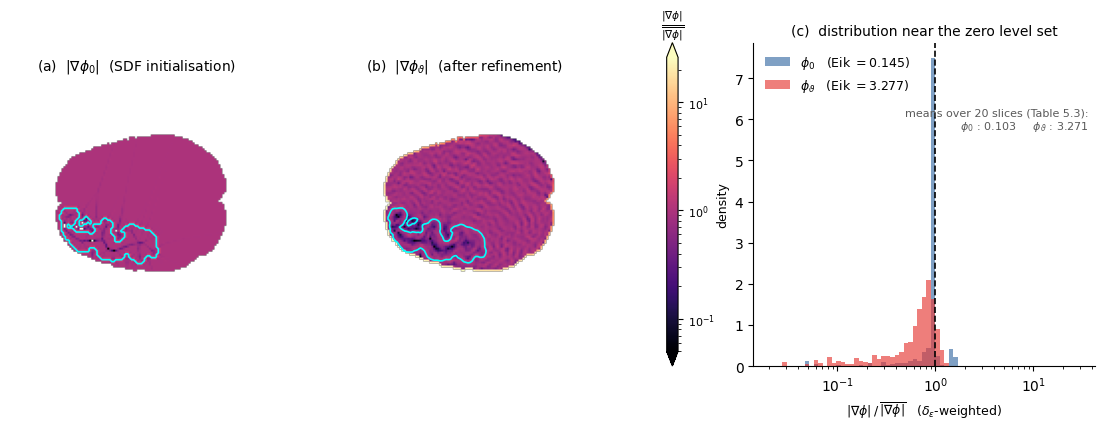

{'k': 18,
 'phi0': array([[-2.9773607, -2.9618037, -2.9467564, ..., -3.9508862, -3.9752998,
         -4.       ],
        [-2.938759 , -2.9229965, -2.9077485, ..., -3.9169855, -3.9416091,
         -3.9665194],
        [-2.9002445, -2.8842719, -2.8688178, ..., -3.883238 , -3.9080741,
         -3.9331968],
        ...,
        [-2.1289852, -2.101375 , -2.0742378, ..., -2.61714  , -2.6518803,
         -2.68682  ],
        [-2.1602805, -2.1330755, -2.1063468, ..., -2.640681 , -2.6751156,
         -2.709756 ],
        [-2.1919243, -2.165117 , -2.1387887, ..., -2.6646683, -2.6987967,
         -2.733137 ]], dtype=float32),
 'phi': array([[-2.055905, -2.055905, -2.055905, ..., -2.055905, -2.055905,
         -2.055905],
        [-2.055905, -2.055905, -2.055905, ..., -2.055905, -2.055905,
         -2.055905],
        [-2.055905, -2.055905, -2.055905, ..., -2.055905, -2.055905,
         -2.055905],
        ...,
        [-2.055905, -2.055905, -2.055905, ..., -2.055905, -2.055905,
         -2.05590

In [4]:
# =====================================================================
#  FIGURE CELL -- eikonal deviation, Chapter 5 (Figure accompanying
#  Table 5.3).
#
#  Run this AFTER the measurement cell, in the same session.
#  It recomputes nothing: it reads back the fields stored during
#  PASS 1 and reuses acc["e0"] / acc["e1"], so the numbers printed on
#  the figure are the ones already in Table 5.3 by construction.
#
#  Requires three lines added to the PASS 1 loop -- see below.
# =====================================================================

# ---------------------------------------------------------------------
#  STEP 0 -- modification to make in the PASS 1 loop
# ---------------------------------------------------------------------
#  Before the loop, add:
#
#      fields = []
#
#  Inside the loop, after `rm = clean_mask((phi > 0) & brain)`, add:
#
#      fields.append({"k": k, "phi0": phi0.copy(),
#                     "phi": phi.copy(), "brain": brain.copy()})
#
#  Memory cost: 3 arrays of 128x128 float32 per slice, about 4 MB for
#  20 slices. Nothing else changes.
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# ---------------------------------------------------------------------
#  1. Weighted statistics -- IDENTICAL to eikonal_deviation()
# ---------------------------------------------------------------------
def _grad_and_weights(phi, eps, h=1.0):
    """Returns |grad phi| and the delta_eps weights, exactly as they are
    formed inside eikonal_deviation(). Keeping this in one place is what
    guarantees that the figure and Table 5.3 cannot disagree."""
    gy, gx = np.gradient(phi.astype(np.float64), h)
    g = np.sqrt(gx ** 2 + gy ** 2)
    w = _delta_eps(phi.astype(np.float64), eps)
    return g, w


def _weighted_mean(g, w):
    return float(np.sum(w * g) / (np.sum(w) + 1e-12))


# ---------------------------------------------------------------------
#  2. Figure
# ---------------------------------------------------------------------
def eikonal_figure(fields, e0_list, e1_list, eps, item=None,
                   save="/kaggle/working/fig_eikonal.pdf", dpi=300):
    """fields   : list built in PASS 1
       e0_list  : acc["e0"]      e1_list : acc["e1"]
       item     : a specific entry of `fields`; if None the slice whose
                  post-refinement deviation is closest to the mean of
                  e1_list is used. Picking the best-Dice slice would be
                  the wrong choice here: the figure documents a defect,
                  so it must show a typical case, not a favourable one."""
    e0 = np.asarray(e0_list, dtype=float)
    e1 = np.asarray(e1_list, dtype=float)

    if item is None:
        j = int(np.argmin(np.abs(e1 - e1.mean())))
        item = fields[j]
    else:
        j = fields.index(item)

    phi0, phi, brain = item["phi0"], item["phi"], item["brain"]

    g0, w0 = _grad_and_weights(phi0, eps)
    g1, w1 = _grad_and_weights(phi, eps)
    mu0, mu1 = _weighted_mean(g0, w0), _weighted_mean(g1, w1)

    # Normalisation by the weighted mean. phi0 is a RESCALED signed-
    # distance function (prob_to_phi0 divides by max|phi0| and multiplies
    # by phi_scale), so |grad phi0| is constant but is NOT 1. Plotting the
    # raw magnitude against a reference line at 1 would contradict
    # Table 5.3. The ratio below is the quantity whose weighted standard
    # deviation IS the tabulated eikonal deviation.
    g0n, g1n = g0 / (mu0 + 1e-12), g1 / (mu1 + 1e-12)

    # refine() sets phi outside the brain to phi[brain].min(), which
    # creates a step at the skull and a bright artificial ring in the
    # gradient. It is invisible in the metric (delta_eps is ~0 there) but
    # would dominate the map, so it is masked out.
    m0 = np.where(brain, g0n, np.nan)
    m1 = np.where(brain, g1n, np.nan)
    vmin, vmax = 0.05, max(3.0, np.nanpercentile(m1, 99.5))

    fig = plt.figure(figsize=(14, 4.2))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 0.045, 1.35], wspace=0.35)
    ax = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]),
          fig.add_subplot(gs[0, 3])]
    cax = fig.add_subplot(gs[0, 2])

    for a, m, t, ph in [
        (ax[0], m0, r"(a)  $|\nabla\phi_0|$  (SDF initialisation)", phi0),
        (ax[1], m1, r"(b)  $|\nabla\phi_\vartheta|$  (after refinement)", phi),
    ]:
        im = a.imshow(m, cmap="magma", norm=LogNorm(vmin=vmin, vmax=vmax))
        a.contour(ph, levels=[0.0], colors="cyan", linewidths=1.2)
        a.set_title(t, fontsize=10)
        a.axis("off")
    cb = fig.colorbar(im, cax=cax, extend="both")
    cb.ax.tick_params(labelsize=8)
    cax.set_title(r"$\frac{|\nabla\phi|}{\overline{|\nabla\phi|}}$",
                  fontsize=11, pad=10)

    # Weighted histogram: the delta_eps weights are the same ones used by
    # eikonal_deviation, so panel (c) is literally the distribution whose
    # coefficient of variation the table reports.
    sel_px = brain & (w1 > 1e-4)
    hi = max(6.0, np.nanpercentile(g1n[sel_px], 99.9))
    bins = np.logspace(np.log10(0.02), np.log10(hi), 70)
    ax[2].hist(g0n[brain].ravel(), bins=bins, weights=w0[brain].ravel(),
               density=True, alpha=0.65, color="#3b6ea5",
               label=r"$\phi_0$   (Eik $=%.3f$)" % e0[j])
    ax[2].hist(g1n[brain].ravel(), bins=bins, weights=w1[brain].ravel(),
               density=True, alpha=0.65, color="#E53935",
               label=r"$\phi_\vartheta$   (Eik $=%.3f$)" % e1[j])
    ax[2].axvline(1.0, color="k", ls="--", lw=1.2)
    ax[2].set_xscale("log")
    ax[2].set_xlabel(r"$|\nabla\phi|\,/\,\overline{|\nabla\phi|}$"
                     r"   ($\delta_\varepsilon$-weighted)", fontsize=9)
    ax[2].set_ylabel("density", fontsize=9)
    ax[2].set_title("(c)  distribution near the zero level set", fontsize=10)
    ax[2].legend(fontsize=9, frameon=False, loc="upper left")
    ax[2].spines[["top", "right"]].set_visible(False)
    ax[2].text(0.98, 0.80,
               "means over %d slices (Table 5.3):\n"
               r"$\phi_0$ : %.3f     $\phi_\vartheta$ : %.3f"
               % (len(e1), np.nanmean(e0), np.nanmean(e1)),
               transform=ax[2].transAxes, ha="right", va="top",
               fontsize=8, color="0.35")

    fig.savefig(save, dpi=dpi, bbox_inches="tight")
    print(f"[INFO] figure -> {save}")
    print(f"[INFO] slice shown: k={item['k']}   "
          f"Eik {e0[j]:.4f} -> {e1[j]:.4f}")
    print(f"[INFO] means over {len(e1)} slices: "
          f"{np.nanmean(e0):.4f} -> {np.nanmean(e1):.4f}  (Table 5.3)")
    plt.show()
    return item


# ---------------------------------------------------------------------
#  3. Call
# ---------------------------------------------------------------------
eikonal_figure(fields, acc["e0"], acc["e1"], config["delta_eps"])